# Taller 05: Clustering DBSCAN
**Inteligencia Artificial - Universidad del Norte**
## Integrantes:
- Wilmer Santiago
- Bryan Montoya
- Andrea Quintero

En este notebook:
1. Generamos un conjunto de datos sintético en 2D a partir de una figura propia con grupos amorfos.
2. Agregamos outliers distribuidos uniformemente.
3. Analizamos gráficos de k-distancia para varios valores de `MinPts` y seleccionamos `eps` mediante detección automática del codo (punto de inflexión).
4. Aplicamos DBSCAN y evaluamos el resultado con dos métricas de `sklearn.metrics`: **Adjusted Rand Index** y **Silhouette Score**.


In [6]:
import numpy as np
from PIL import Image
from scipy import ndimage
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score

Semilla fija y arbitraria para que la generación de puntos, outliers y el resto del notebook sean reproducibles entre ejecuciones.

In [7]:
np.random.seed(42)

## Cargar la figura
La imagen `imagen.png`, figura propia con los grupos amorfos, se guarda en la misma carpeta del repositorio que este notebook.

In [5]:
imagen = Image.open('imagen.png').convert('L')
imagen_array = np.array(imagen)


## Binarizar la imagen

Como se escaló la imagen a tonos de grises, de 0 (negro) a 255 (blanco), solo seleccionamos aquellos que tengan una intensidad menor a 128 (más oscuro que claro)

In [3]:
umbral = 128
binaria = imagen_array < umbral

Pixeles marcados como figura: 83603 de 627638
Porcentaje de figura: 13.32%


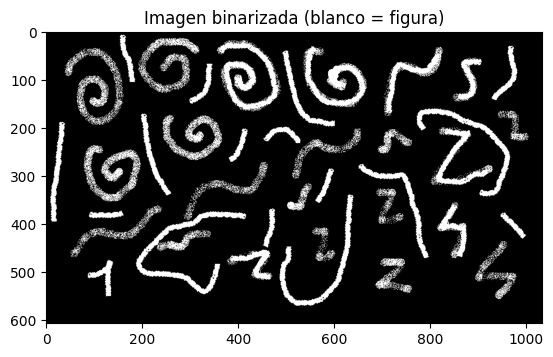

In [4]:
print(f'Pixeles marcados como figura: {binaria.sum()} de {binaria.size}')
print(f'Porcentaje de figura: {(binaria.sum()/binaria.size*100).round(3)}%')
plt.imshow(binaria, cmap='gray')
plt.title("Imagen binarizada (blanco = figura)")
plt.show()


## Detectar los grupos reales de la figura
Para nuestro caso de estudio, la figura de está dibujada con una textura punteada/granulada, por lo que etiquetar directamente los componentes conectados del array `binaria` produce cientos de fragmentos accidentales y no los ~30-40 grupos amorfos reales que dibujamos.

Para resolverlo, aplicamos una dilatación morfológica que une los puntos cercanos de un mismo trazo antes de etiquetar los componentes conectados, y luego descartamos componentes demasiado pequeños. Para ello, buscamos automáticamente la cantidad mínima de iteraciones de dilatación que deja el número de grupos dentro de un rango razonable entre 25–40 grupos, en vez de fijar un valor arbitrario a mano.

In [21]:
def contar_grupos(binaria, iteraciones, min_pixeles, estructura):
    if iteraciones == 0:
        conectada = binaria
    else:
        conectada = ndimage.binary_dilation(binaria, structure=estructura, iterations=iteraciones)
    etiquetas, n = ndimage.label(conectada)
    if n == 0:
        return etiquetas, np.array([], dtype=int), np.array([])
    tamanos = ndimage.sum(binaria, etiquetas, range(1, n + 1))
    grandes = np.where(tamanos >= min_pixeles)[0] + 1
    return etiquetas, grandes, tamanos

estructura = np.ones((3, 3))
# descarta manchas de textura muy pequeñas
min_pixeles = max(30, int(0.002 * binaria.sum()))
# rango deseado de grupos según nuestro dibujo
objetivo_min, objetivo_max = 25, 40
objetivo_medio = (objetivo_min + objetivo_max) / 2

mejor_it, mejor_diff = None, None
resultados_por_iteracion = {}
for it in range(0, 20):
    etiquetas, grandes, tamanos = contar_grupos(binaria, it, min_pixeles, estructura)
    n = len(grandes)
    resultados_por_iteracion[it] = n
    diff = abs(n - objetivo_medio)
    if mejor_it is None or diff < mejor_diff:
        mejor_it, mejor_diff = it, diff
    if objetivo_min <= n <= objetivo_max:
        mejor_it = it
        break

print('Grupos detectados según iteraciones:', resultados_por_iteracion)

etiquetas, grupos_validos, tamanos = contar_grupos(binaria, mejor_it, min_pixeles, estructura)
n_grupos = len(grupos_validos)
print(f'Iteraciones seleccionada: {mejor_it}')
print(f'Grupos detectados (reales, filtrando ruido de textura): {n_grupos}')


Grupos detectados según iteraciones: {0: 51, 1: 38}
Iteraciones seleccionada: 1
Grupos detectados (reales, filtrando ruido de textura): 38


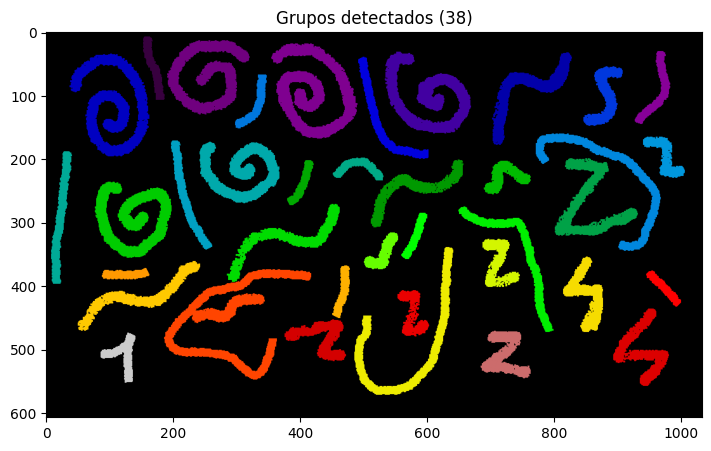

In [23]:
mapa_grupos = np.where(np.isin(etiquetas, grupos_validos), etiquetas, 0)
plt.figure(figsize=(10, 5))
plt.imshow(mapa_grupos, cmap='nipy_spectral')
plt.title(f'Grupos detectados ({n_grupos})')
plt.show()


## Generar puntos sintéticos por grupo
Para cada grupo real detectado, muestreamos píxeles de la figura original (`binaria`, sin dilatar) que pertenecen a ese grupo, y les agregamos un pequeño ruido gaussiano (jitter) para obtener coordenadas continuas en 2D.

In [25]:
puntos_x, puntos_y, etiqueta_real = [], [], []
puntos_por_grupo = 40
ruido_jitter = 0.8

for nuevo_id, grupo_id in enumerate(grupos_validos, start=1):
    filas, cols = np.where((etiquetas == grupo_id) & binaria)
    if len(filas) == 0:
        continue
    idx = np.random.choice(len(filas), size=min(puntos_por_grupo, len(filas)), replace=False)
    for i in idx:
        x = cols[i] + np.random.normal(0, ruido_jitter)
        y = filas[i] + np.random.normal(0, ruido_jitter)
        puntos_x.append(x)
        puntos_y.append(y)
        etiqueta_real.append(nuevo_id)

print(f'Puntos generados: {len(puntos_x)} repartidos en {n_grupos} grupos')


Puntos generados: 1520 repartidos en 38 grupos


## Generar outliers
Además de los puntos generados dentro de cada grupo, agregamos outliers distribuidos de manera uniforme sobre todo el plano de la imagen, simulando ruido real y permitiendo evaluar si DBSCAN los identifica correctamente como tal.

In [27]:
proporcion_outliers = 0.05
n_outliers = int(proporcion_outliers * len(puntos_x))

alto, ancho = binaria.shape
outliers_x = np.random.uniform(0, ancho, n_outliers)
outliers_y = np.random.uniform(0, alto, n_outliers)

# Dataset final
X = np.column_stack([
    puntos_x + list(outliers_x),
    puntos_y + list(outliers_y)
])
y_real = np.array(etiqueta_real + [-1] * n_outliers)

print(f'Total de puntos: {X.shape[0]} ({len(puntos_x)} de grupos + {n_outliers} outliers)')
print(f'Número de grupos reales: {n_grupos}')


Total de puntos: 1596 (1520 de grupos + 76 outliers)
Número de grupos reales: 38


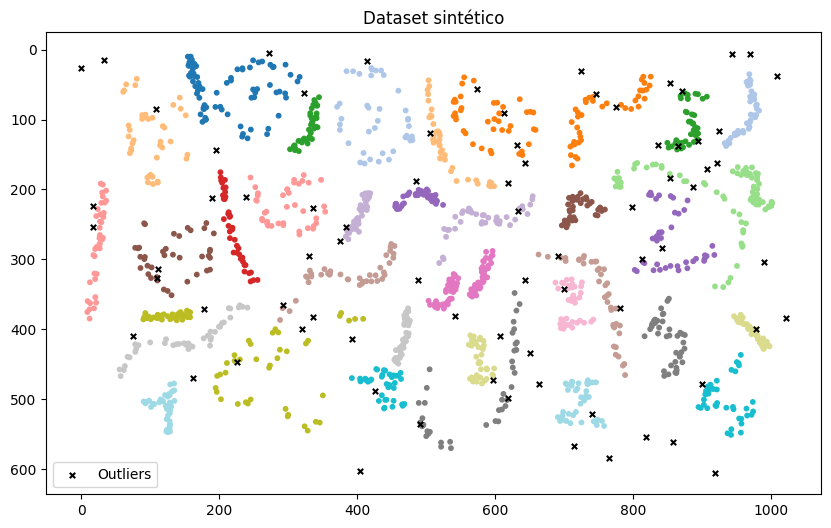

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(X[y_real != -1, 0], X[y_real != -1, 1], c=y_real[y_real != -1], cmap='tab20', s=10)
plt.scatter(X[y_real == -1, 0], X[y_real == -1, 1], c='black', marker='x', s=15, label='Outliers')
plt.gca().invert_yaxis()
plt.title('Dataset sintético')
plt.legend()
plt.show()


## Análisis exploratorio: gráficos de k-distancia para varios $MinPts$
Para estimar $\varepsilon$ y $MinPts$, seguimos la heurística estándar de DBSCAN: para cada candidato de $MinPts = k$, se calcula la distancia de cada punto a su k-ésimo vecino más cercano, se ordenan esas distancias de mayor a menor y se grafican. El punto de inflexión de la curva indica el valor de $\varepsilon$ a partir del cual los puntos dejan de pertenecer claramente a un vecindario denso.

En vez de fijar $MinPts$ a un único valor, probamos varios candidatos alrededor de la regla práctica $MinPts ≈ 2 \times dimensiones$ (en el caso de 2D $MinPts = 4$), y comparamos el resultado de DBSCAN para cada uno, incluyendo las métricas de evaluación, para justificar cuál es el más adecuado en este dataset.

El codo de cada curva se detecta automáticamente (método tipo *kneedle*): se traza la recta entre el primer y el último punto de la curva normalizada, y se toma como codo el punto con mayor distancia vertical a esa recta.

In [30]:
def encontrar_codo(valores):
    y = np.asarray(valores, dtype=float)
    x = np.arange(len(y))
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)
    linea = y_norm[0] + (y_norm[-1] - y_norm[0]) * x_norm
    distancias = linea - y_norm
    return int(np.argmax(distancias))


### Selección de $ɛ$ y $MinPts$
De la tabla anterior, elegimos la combinación con la mejor coincidencia con los grupos reales, usando el Silhouette Score como criterio de desempate si dos configuraciones quedan muy cerca en ARI. Este criterio es válido aquí porque conocemos `y_real` por construcción; en un escenario sin verdad fundamental, la selección se apoyaría solo en la forma del codo y en el Silhouette Score.

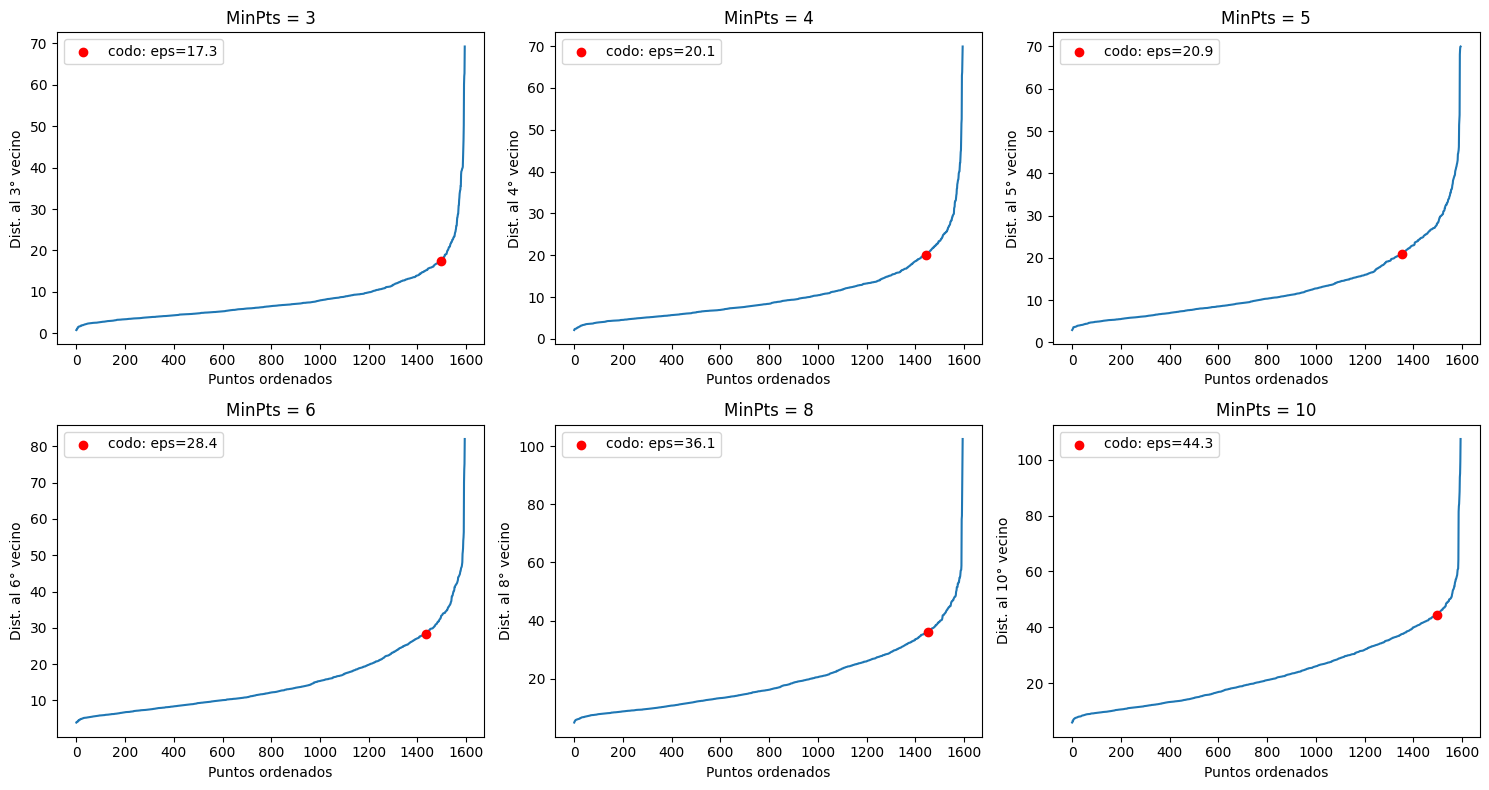

 MinPts      eps  clusters   ruido     ARI  Silhouette
      3    17.34        92      67   0.710       0.440
      4    20.10        79      68   0.730       0.429
      5    20.87        68     126   0.674       0.458
      6    28.42        33      62   0.598       0.330
      8    36.06        14      53   0.216       0.130
     10    44.26         4      24   0.048       0.068


In [46]:
candidatos_minpts = [3, 4, 5, 6, 8, 10]
resultados_sweep = []

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, min_pts in zip(axes.ravel(), candidatos_minpts):
    vecinos = NearestNeighbors(n_neighbors=min_pts).fit(X)
    distancias, _ = vecinos.kneighbors(X)
    k_dist = np.sort(distancias[:, min_pts - 1])[:-1]
    idx_codo = encontrar_codo(k_dist)
    eps = k_dist[idx_codo]

    ax.plot(k_dist)
    ax.scatter([idx_codo], [eps], color='red', zorder=5, label=f'codo: eps={eps:.1f}')
    ax.set_title(f'MinPts = {min_pts}')
    ax.set_xlabel('Puntos ordenados')
    ax.set_ylabel(f'Dist. al {min_pts}° vecino')
    ax.legend()

    db = DBSCAN(eps=eps, min_samples=min_pts).fit(X)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = list(labels).count(-1)
    mascara = labels != -1
    ari = adjusted_rand_score(y_real, labels)
    sil = silhouette_score(X[mascara], labels[mascara]) if mascara.sum() > 1 and len(set(labels[mascara])) > 1 else float('nan')
    resultados_sweep.append({
        'min_pts': min_pts, 'eps': eps, 'n_clusters': n_clusters,
        'n_ruido': n_ruido, 'ari': ari, 'silhouette': sil, 'labels': labels
    })

plt.tight_layout()
plt.show()

print(f"{'MinPts':>7} {'eps':>8} {'clusters':>9} {'ruido':>7} {'ARI':>7} {'Silhouette':>11}")
for r in resultados_sweep:
    print(f"{r['min_pts']:>7} {r['eps']:>8.2f} {r['n_clusters']:>9} {r['n_ruido']:>7} {r['ari']:>7.3f} {r['silhouette']:>11.3f}")


Ahora bien, aunque $MinPts=3$ obtiene mayor ARI, produce 91 clusters frente a los 38 reales, esto es evidencia de una sobre-fragmentación por el ruido de textura de la imagen. Es por ello, que a pesar de todo, preferimos seleccionar manualmente $MinPts=5$, cuyo número de clusters 36 es mucho más consistente y cercano con la estructura real de los datos a pesar de una caída moderada en ARI

In [42]:
mejor = list(filter(lambda x: x['min_pts'] == 5,resultados_sweep))[0]
min_pts_final = mejor['min_pts']
eps_final = mejor['eps']
etiquetas_dbscan = mejor['labels']

n_clusters = mejor['n_clusters']
n_ruido = mejor['n_ruido']

print(f'MinPts seleccionado: {min_pts_final}')
print(f'eps seleccionado: {eps_final:.2f}')
print(f'Clusters encontrados: {n_clusters} (grupos reales: {n_grupos})')
print(f'Puntos clasificados como ruido: {n_ruido} ({n_ruido/len(X)*100:.1f}%)')


MinPts seleccionado: 5
eps seleccionado: 27.14
Clusters encontrados: 36 (grupos reales: 38)
Puntos clasificados como ruido: 42 (2.6%)


In [ ]:
plt.figure(figsize=(10, 6))
mascara_ruido = etiquetas_dbscan == -1
plt.scatter(X[~mascara_ruido, 0], X[~mascara_ruido, 1], c=etiquetas_dbscan[~mascara_ruido], cmap='tab20', s=10)
plt.scatter(X[mascara_ruido, 0], X[mascara_ruido, 1], c='black', marker='x', s=15, label='Ruido')
plt.gca().invert_yaxis()
plt.title(f'Resultado de DBSCAN (eps={eps_final:.2f}, MinPts={min_pts_final})')
plt.legend()
plt.show()


## Evaluación de desempeño del clustering
Para la evaluación usamos dos métricas complementarias de scikit-learn:

## 1. Adjusted Rand Index (ARI) — métrica *extrínseca*
Compara las etiquetas predichas por DBSCAN contra los grupos reales que usamos para generar los datos (`y_real`), corrigiendo por asignaciones coincidentes al azar. Es posible calcularla aquí porque, al construir el dataset sintéticamente, conocemos la verdad fundamental (a qué grupo de la figura pertenece cada punto).
## 2. Silhouette Score — métrica *intrínseca*
Mide qué tan bien separados y compactos son los clusters usando solo las distancias entre puntos, sin necesitar las etiquetas reales. Se calcula excluyendo los puntos etiquetados como ruido (-1), ya que el ruido no pertenece a ningún cluster.

In [44]:
ari_final = adjusted_rand_score(y_real, etiquetas_dbscan)

mascara_valida = etiquetas_dbscan != -1
if mascara_valida.sum() > 1 and len(set(etiquetas_dbscan[mascara_valida])) > 1:
    silhouette_final = silhouette_score(X[mascara_valida], etiquetas_dbscan[mascara_valida])
else:
    silhouette_final = float('nan')

print(f'Adjusted Rand Index (vs. grupos reales): {ari_final:.3f}')
print(f'Silhouette Score (excluyendo ruido): {silhouette_final:.3f}')


Adjusted Rand Index (vs. grupos reales): 0.628
Silhouette Score (excluyendo ruido): 0.327


## Conclusión

- Grupos reales detectados en la figura: 38
- Valores de MinPts comparados: `[3, 4, 5, 6, 8, 10]`
- Configuración elegida: MinPts = 5, eps = 27.14
- Clusters encontrados por DBSCAN: 36 de 38 grupos reales
- Puntos clasificados como ruido: 42 (2.6%)
- Adjusted Rand Index: 0.628 -> una coincidencia moderada con los grupos reales
- Silhouette Score: 0.327 -> clusters moderadamente separados, con algo de solapamiento